In [2]:
import nltk

<h4> Zadanie1: Czy fakt, że nie oczyściliśmy danych ze stopwords czy znaków interpunkcyjncyh znacząco wpłynął na pogorszenie predykcji? Odpowiedź uzasadnij (bez obliczeń, chodzi o 2 zdania komentarza).

Odp 1.
Brak oczyszczenia nie wpłynał znaczaco na pogorszenie predykcji, bo stopwordsy nie niosa informacji nacechowanych pozytywnie czy negatywnie.
Moga powodować nadmiarowość danych, ale wpływa to marginalnie na predykcje. Nasze główne słowa na których opiera się predykcja i tak występuja.

<h4> Zadanie2: Powtórz 20 razy predykcję za pomocą metody Naive Bayes za każdym razem tasując listę documents (po co?). Zapisz do listy dokładności uzyskane za każdym razem. Wyznacz średnią dokładność i odchylenie standardowe z tych dokładności (wcześniej przerób listę na obiekt typu array). Narysuj histogram dokładności.

In [3]:
import nltk
from nltk.corpus import movie_reviews
import random

documents = [] 
iteracje = 20

for category in movie_reviews.categories(): 
    for fileid in movie_reviews.fileids(category):
        documents.append((list(movie_reviews.words(fileid)), category))

random.shuffle(documents)
all_words = []

for w in movie_reviews.words():
    all_words.append(w.lower())

all_words = nltk.FreqDist(all_words) 

word_features = [x[0] for x in all_words.most_common(3000)]

In [4]:
def find_features(document): #przez document rozumiemy tutaj lista wyrazow
    words = set(document)    #patrze na unikatowe slowa
    features = {}            #tworzę pusty slownik
    for w in word_features: #word_features zdefiniowane wyzej [lista 3000 najczęstych slow we wszystkich recenzjach]
        features[w] = (w in words) #True or False, dla kazdego slowa z word_features w zaleznosci czy jest czy nie w dokumencie
    return features

In [5]:
#Pętla iterujaca
dokladnosci = []
iteracje = 20

for i in range(iteracje): 
    random.shuffle(documents)
    
    featuresets = [(find_features(rev), category) for (rev, category) in documents]
    training_set = featuresets[:1900]
    testing_set = featuresets[1900:]
    
    classifier = nltk.NaiveBayesClassifier.train(training_set)
    
    dokladnosc = nltk.classify.accuracy(classifier, testing_set) * 100
    dokladnosci.append(dokladnosc)
    print(f"Iteracja {i+1}: {dokladnosc}%")

Iteracja 1: 77.0%
Iteracja 2: 78.0%
Iteracja 3: 84.0%
Iteracja 4: 77.0%
Iteracja 5: 81.0%
Iteracja 6: 81.0%
Iteracja 7: 84.0%
Iteracja 8: 79.0%
Iteracja 9: 81.0%
Iteracja 10: 79.0%
Iteracja 11: 83.0%
Iteracja 12: 86.0%
Iteracja 13: 83.0%
Iteracja 14: 75.0%
Iteracja 15: 83.0%
Iteracja 16: 79.0%
Iteracja 17: 82.0%
Iteracja 18: 78.0%
Iteracja 19: 83.0%
Iteracja 20: 86.0%


In [6]:
import numpy as np
dokl_arr = np.array(dokladnosci)

srednia_dokladnosc = np.mean(dokl_arr)
odchylenie = np.std(dokl_arr)

print(f'Średnia dokładność: {srednia_dokladnosc}')
print(f'Odchylenie standardowe: {odchylenie}')

Średnia dokładność: 80.95
Odchylenie standardowe: 3.0244834269673224


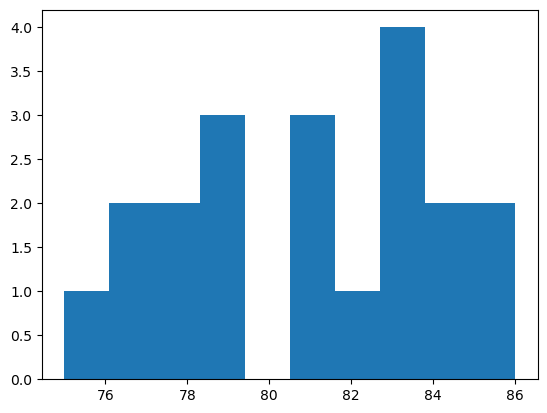

In [7]:
#Histogram dokładności
import matplotlib.pyplot as plt
plt.hist(dokladnosci)
plt.show()

<h4> Zadanie3: Wyjaśnij czemu istotnym jest aby grupy tekstów reprezentujących klasy były w miarę równoliczne. Zbuduj model NaiveBayes, gdzie jako zbiór treningowy wybierz 900 recenzji pozytywnych i 100 negatywnych. Następnie zabadaj jak model sprawdza się na 100 pozostałych recenzjach pozytywnych a jak na 100 negatywnych (innych niż przy trenowaniu modelu). Skomentuj otrzymane wyniki.

In [8]:
pos_ids = movie_reviews.fileids('pos')
neg_ids = movie_reviews.fileids('neg')

def find_features_for_ids(ids, category):
    return [(find_features(movie_reviews.words(fileid)), category) for fileid in ids]
    
#Zbiór treningowy
train_pos = find_features_for_ids(pos_ids[:900], 'pos')
train_neg = find_features_for_ids(neg_ids[:100], 'neg')
training_set = train_pos + train_neg

# Zbiór testowy
test_pos = find_features_for_ids(pos_ids[900:], 'pos')
test_neg = find_features_for_ids(neg_ids[100:], 'neg')
testing_set = test_pos + test_neg

classifier = nltk.NaiveBayesClassifier.train(training_set)

In [9]:
accuracy = nltk.classify.accuracy(classifier, testing_set) * 100
print(f"Dokładność na zbiorze testowym: {accuracy:.2f}%")

classifier.show_most_informative_features(10)

Dokładność na zbiorze testowym: 41.00%
Most Informative Features
                 idiotic = True              neg : pos    =     19.6 : 1.0
                  prinze = True              neg : pos    =     16.6 : 1.0
              henstridge = True              neg : pos    =      8.9 : 1.0
                   snake = True              neg : pos    =      7.9 : 1.0
                   inept = True              neg : pos    =      7.3 : 1.0
               memorable = True              pos : neg    =      6.8 : 1.0
                 tedious = True              neg : pos    =      6.8 : 1.0
                  poorly = True              neg : pos    =      6.8 : 1.0
                    skip = True              neg : pos    =      6.5 : 1.0
                    mess = True              neg : pos    =      6.5 : 1.0


In [10]:
#Inny zestaw recenzji
train_pos = find_features_for_ids(pos_ids[:900], 'pos')
train_neg = find_features_for_ids(neg_ids[300:400], 'neg')
training_set = train_pos + train_neg

test_pos = find_features_for_ids(pos_ids[900:], 'pos')
test_neg = find_features_for_ids(neg_ids[400:500], 'neg')

classifier = nltk.NaiveBayesClassifier.train(training_set)

acc_pos = nltk.classify.accuracy(classifier, test_pos) * 100
acc_neg = nltk.classify.accuracy(classifier, test_neg) * 100

print(f"Dokładność dla recenzji pozytywnych: {acc_pos:.2f}%")
print(f"Dokładność dla recenzji negatywnych: {acc_neg:.2f}%")

Dokładność dla recenzji pozytywnych: 97.00%
Dokładność dla recenzji negatywnych: 36.00%


Odp 3. Najpierw otrzymaliśmy dokładność na zbiorze testowym (dla pos i neg) 41%, po rozbiciu dokładności dla obydwu rodzai recenzji widać, że recenzje pozytywne, dla których zbiór treningowy wynosił 900, dokładność wynosi 97%; podczas gdy dla recenzji negatywnych (dla których wybrano inny zestaw 100 recenzji, ale dalej mała próbke do nauki), dokładność wynosi 36%. Takie dysproporcje moga wyraźnie obniżać ogólna dokładność i zaburzać analizę. 

<h4> Zadanie4: Zbuduj model do predykcji wiadomości SPAM/HAM. W tym celu użyj pliku  spam_ham.txt . Każda wiadomość opatrzona jest odpowiednim tagiem na początku kolejnego wiersza. Sprawdź ile w pliku znajduje się wiadomości typu SPAM i HAM. Uwzględnij uwagę z poprzedniego zadania.

In [11]:
import nltk
from nltk.tokenize import word_tokenize
import re

with open('spam_ham.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()
    
ham_docs = []
spam_docs = []

#Ile wiadomości SPAM/HAM w pliku
for line in lines:
    match = re.match(r'^(ham|spam)(.*)', line)
    if match:
        label = match.group(1).lower()
        text = match.group(2)
        words = re.findall(r'\w+', text.lower())
        
        if label == 'ham':
            ham_docs.append((words, 'ham'))
        else:
            spam_docs.append((words, 'spam'))        

#Balansujemy zbyt duża ilość HAM, wybieramy tyle HAm ile mamy SPAM
ham_docs_balanced = random.sample(ham_docs, len(spam_docs))
documents = ham_docs_balanced + spam_docs
random.shuffle(documents)

print(f'Wiadomości typu HAM: {len(ham_docs)}')
print(f'Wiadomości typu SPAM: {len(spam_docs)}')
print(f'Wiadomości typu HAM po zmniejszeniu ilości: {len(ham_docs_balanced)}')

Wiadomości typu HAM: 4827
Wiadomości typu SPAM: 747
Wiadomości typu HAM po zmniejszeniu ilości: 747


In [12]:
#Model 
all_words = []
for (words,label) in documents:
    for w in words:
        all_words.append(w)
        
all_words = nltk.FreqDist(all_words)        
word_features = [x[0] for x in all_words.most_common(2000)]

def find_features(documents): 
    words = set(documents)    
    features = {}            
    for w in word_features: 
        features[w] = (w in words) 
    return features

In [13]:
featuresets = [(find_features(words), label) for (words, label) in documents]
#Wybieram 80% z całego zestawu
limit = int(len(featuresets) * 0.8)

training_set = featuresets[:limit]
testing_set = featuresets[limit:]
classifier = nltk.NaiveBayesClassifier.train(training_set)
accuracy = nltk.classify.accuracy(classifier, testing_set) * 100

In [14]:
print(f"Dokładność modelu na zbiorze testowym: {accuracy}%")
classifier.show_most_informative_features(10)

Dokładność modelu na zbiorze testowym: 95.31772575250837%
Most Informative Features
                     txt = True             spam : ham    =     46.9 : 1.0
                  urgent = True             spam : ham    =     35.7 : 1.0
                      50 = True             spam : ham    =     29.8 : 1.0
                    free = True             spam : ham    =     24.2 : 1.0
                    cash = True             spam : ham    =     23.8 : 1.0
                    draw = True             spam : ham    =     20.6 : 1.0
                     win = True             spam : ham    =     20.6 : 1.0
                  mobile = True             spam : ham    =     20.6 : 1.0
                     box = True             spam : ham    =     20.0 : 1.0
                  latest = True             spam : ham    =     19.3 : 1.0


<h4> Zadanie5: Przeanalizuj dane allegro-reviews za pomocą modelu NaiveBayes. 
    
- Zbuduj model w którym rozważysz tylko recenzje z ocenami 5. i 1.
- Zbuduj model dla pełnych danych.
- Dokonaj modyfikacji, które poprawią te modele.

Uwagi:
- dane są już podzielone na zbiór treningowy i testowy
- dane nie są zbilasnowane, warto coś z tym zrobić
- warto ograniczyć liczbę słów, może jakaś lemmatyzacja?

In [16]:
from datasets import load_dataset

ds = load_dataset("PL-MTEB/allegro-reviews")

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|████| 9577/9577 [00:00<00:00, 260194.65 examples/s]
Generating validation split: 100%|█| 1002/1002 [00:00<00:00, 197522.80 examples/
Generating test split: 100%|█████| 1006/1006 [00:00<00:00, 224296.72 examples/s]


In [44]:
train_data = ds["train"]
test_data = ds["test"]

#Wybór tylko 5. lub 1.
oceny_pos = [d for d in train_data if d["label"] == 5.0]
oceny_neg = [d for d in train_data if d["label"] == 1.0]

X_train = [ex["text"] for ex in train_data]
y_train = [ex["label"] for ex in train_data]

In [45]:
print(f'Ilość recenzji pozytywnych: {len(oceny_pos)}')
print(f'Ilość recenzji negatywnych: {len(oceny_neg)}')

Ilość recenzji pozytywnych: 3923
Ilość recenzji negatywnych: 1733


In [46]:
#Balansujemy ilość recenzji pozytywnych 
pos_balanced = random.sample(oceny_pos, len(oceny_neg))
recenzje_surowe = pos_balanced + oceny_neg
random.shuffle(recenzje_surowe)

In [47]:
#Model
recenzje = []
all_words = []

for d in recenzje_surowe:
    text = d["text"].lower()
    words = text.split() 
    label = d["label"]

    recenzje.append((words, label))
    
    for w in words:
        all_words.append(w)
        
all_words = nltk.FreqDist(all_words)        
word_features = [x[0] for x in all_words.most_common(2000)]

def find_features(document_words): 
    words = set(document_words)    
    features = {}            
    for w in word_features: 
        features[w] = (w in words) 
    return features


In [48]:
featuresets = [(find_features(words), label) for (words, label) in recenzje]
#Wybieram 80% z całego zestawu
limit = int(len(featuresets) * 0.8)

training_set = featuresets[:limit]
testing_set = featuresets[limit:]
classifier = nltk.NaiveBayesClassifier.train(training_set)
accuracy = nltk.classify.accuracy(classifier, testing_set) * 100

In [49]:
print(f"Dokładność modelu na zbiorze testowym: {accuracy}%")
classifier.show_most_informative_features(10)

Dokładność modelu na zbiorze testowym: 87.31988472622479%
Most Informative Features
               pieniędzy = True              1.0 : 5.0    =     31.5 : 1.0
                odradzam = True              1.0 : 5.0    =     29.4 : 1.0
                   zwrot = True              1.0 : 5.0    =     26.0 : 1.0
                 świetny = True              5.0 : 1.0    =     23.3 : 1.0
                  zwrotu = True              1.0 : 5.0    =     18.6 : 1.0
                świetnie = True              5.0 : 1.0    =     16.5 : 1.0
              reklamacja = True              1.0 : 5.0    =     15.2 : 1.0
                 wadliwy = True              1.0 : 5.0    =     14.5 : 1.0
                   dobra = True              5.0 : 1.0    =     14.1 : 1.0
                 porażka = True              1.0 : 5.0    =     13.9 : 1.0
